In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

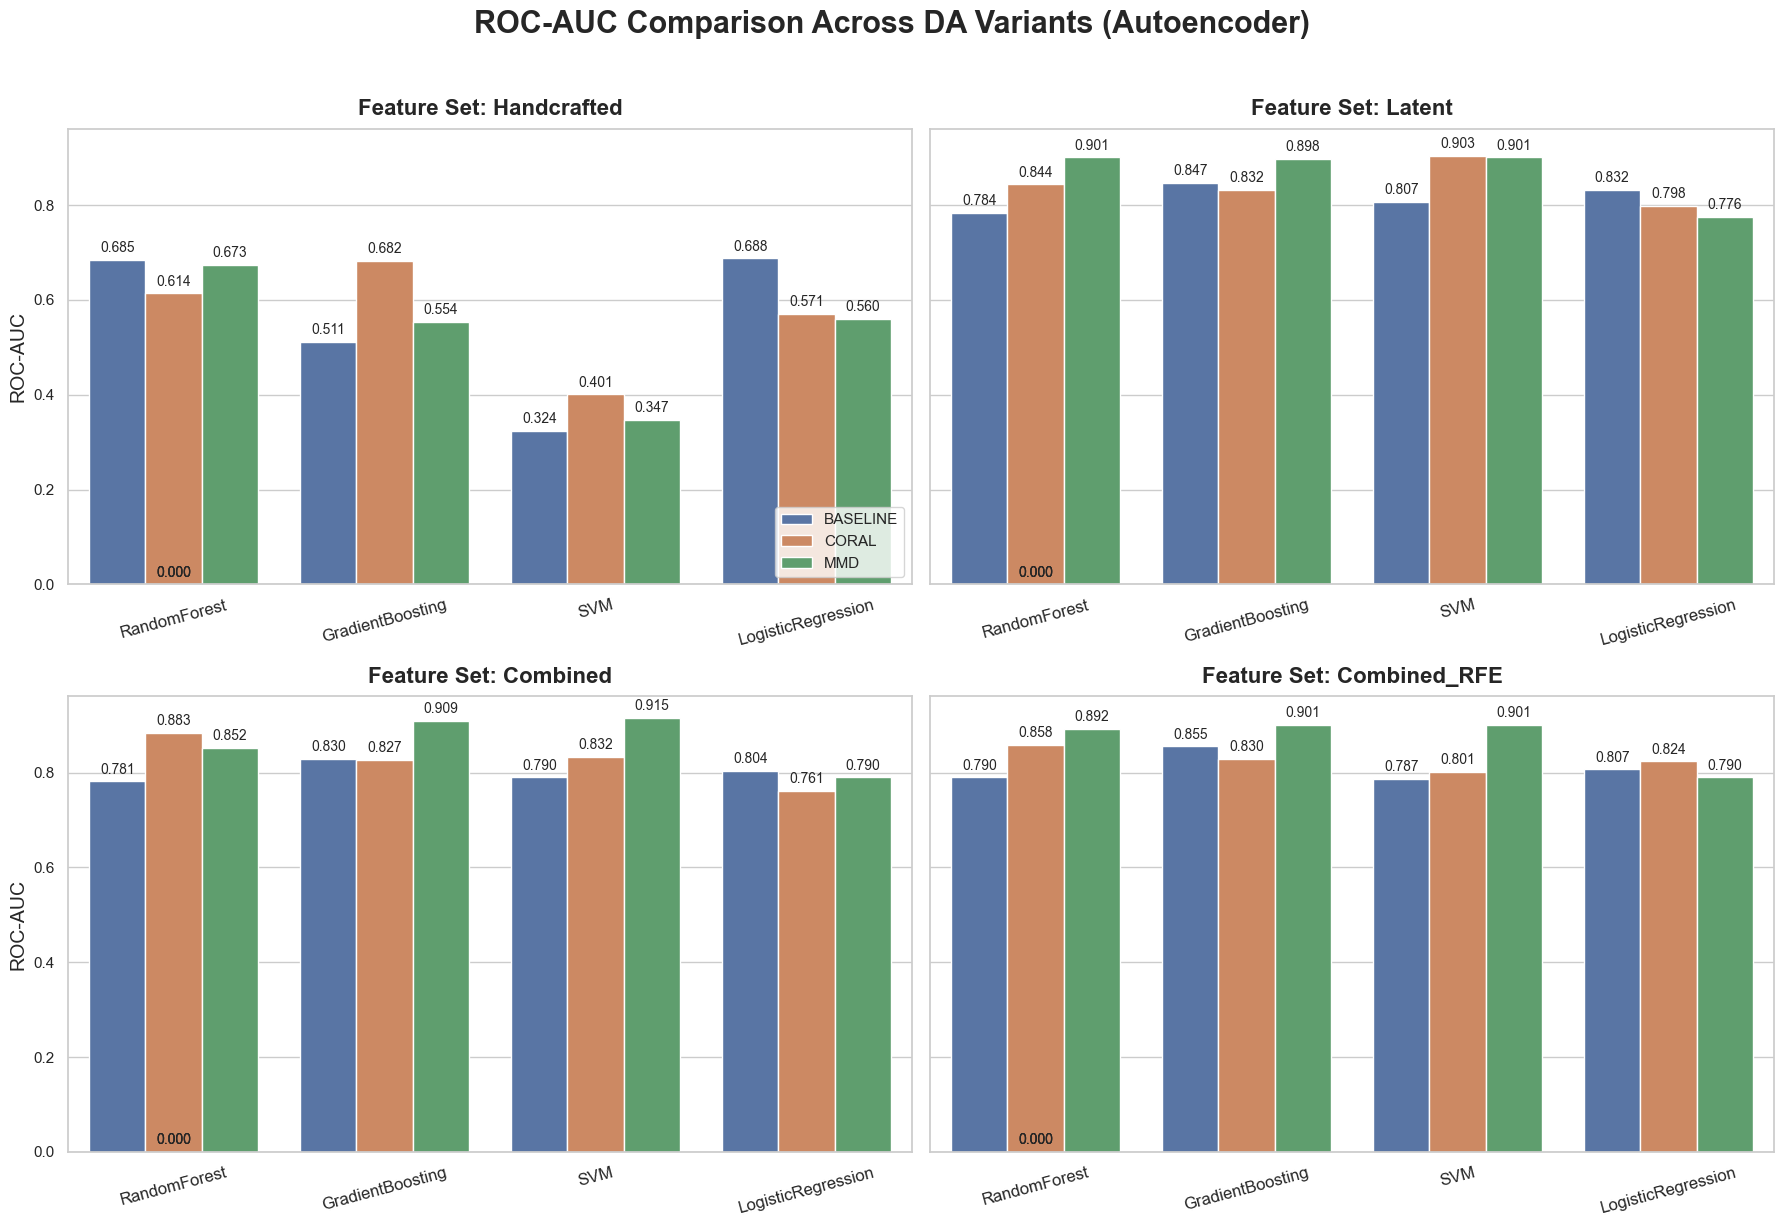

In [2]:
ARCH = "autoencoder"  # Change to "classifier" if evaluating the supervised model
da_variants = ["baseline", "coral", "mmd"]
METRIC = "ROC-AUC"    # Change to "Macro F1" if desired
RESULTS_PATH = "results/" 

# Enforce display order
feature_sets = ["Handcrafted", "Latent", "Combined", "Combined_RFE"]
classifiers = ["RandomForest", "GradientBoosting", "SVM", "LogisticRegression"]
da_order = ["BASELINE", "CORAL", "MMD"]

# ==========================================
# 2. LOAD AND AGGREGATE DATA
# ==========================================
dfs = []
for da in da_variants:
    # Check multiple locations to ensure files are found
    file_path = os.path.join(RESULTS_PATH, f"double_ablation_metrics_{ARCH}_{da}.csv")
    if not os.path.exists(file_path):
        file_path = f"double_ablation_metrics_{ARCH}_{da}.csv"
        
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['DA_Variant'] = da.upper()
        dfs.append(df)
    else:
        print(f"[SKIP] Could not find {file_path}")

if not dfs:
    raise ValueError("No metrics files found. Please run ablation first.")

df_all = pd.concat(dfs, ignore_index=True)

# ==========================================
# 3. PLOTTING (4 Subplots, Grouped Bars)
# ==========================================
sns.set_theme(style="whitegrid", context="notebook")

# Create a 2x2 grid for the 4 feature sets
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten() # Flatten to loop easily

# Define a clean color palette for Baseline, Coral, MMD
colors = ["#4C72B0", "#DD8452", "#55A868"] 

for i, feat in enumerate(feature_sets):
    ax = axes[i]
    subset = df_all[df_all["Feature Set"] == feat]
    
    if subset.empty:
        ax.set_visible(False)
        continue
        
    # Draw grouped bar plot
    sns.barplot(
        data=subset,
        x="Classifier",
        y=METRIC,
        hue="DA_Variant",
        hue_order=da_order,
        order=classifiers,
        palette=colors,
        edgecolor="white",
        ax=ax
    )
    
    # Subplot formatting
    ax.set_title(f"Feature Set: {feat}", fontsize=16, fontweight="bold", pad=10)
    ax.set_xlabel("")
    
    # Only show Y-axis label on the leftmost plots to keep it clean
    if i % 2 == 0:
        ax.set_ylabel(METRIC, fontsize=14)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis='x', rotation=15, labelsize=12)

    # write value on top of bars
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.text(
                p.get_x() + p.get_width() / 2., 
                height + 0.01, 
                f"{height:.3f}", 
                ha="center", 
                va="bottom", 
                fontsize=10
            )
    
    # Consolidate the legend into the first subplot only
    if i == 0:
        ax.legend(fontsize=11, title_fontsize=12, loc="lower right")
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

# Main Figure formatting
fig.suptitle(f"{METRIC} Comparison Across DA Variants ({ARCH.capitalize()})", 
             fontsize=22, fontweight="bold", y=1.02)
# save the figure
plt.savefig(f"results/{ARCH}_{METRIC}_comparison.png", bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

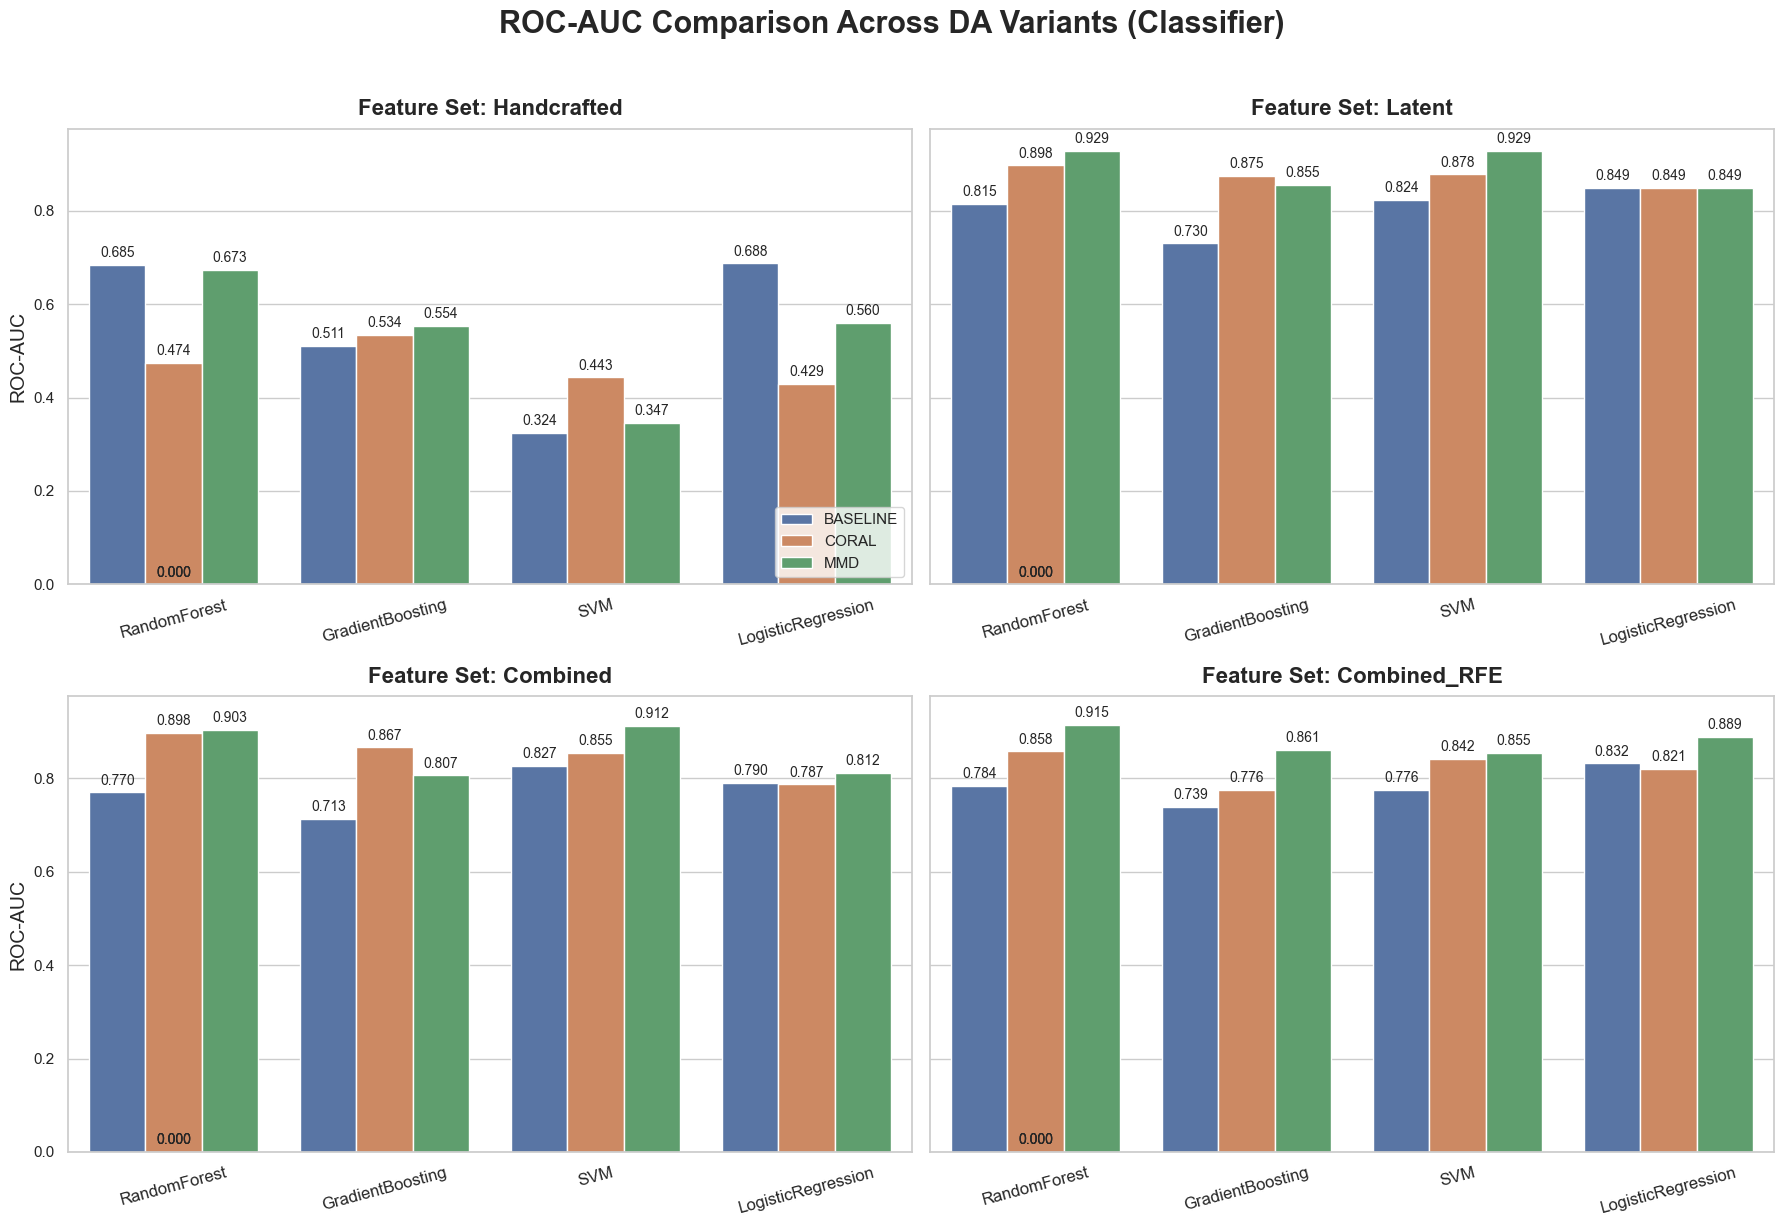

In [3]:
ARCH = "classifier"  # Change to "classifier" if evaluating the supervised model
da_variants = ["baseline", "coral", "mmd"]
METRIC = "ROC-AUC"    # Change to "Macro F1" if desired
RESULTS_PATH = "results/" 

# Enforce display order
feature_sets = ["Handcrafted", "Latent", "Combined", "Combined_RFE"]
classifiers = ["RandomForest", "GradientBoosting", "SVM", "LogisticRegression"]
da_order = ["BASELINE", "CORAL", "MMD"]

# ==========================================
# 2. LOAD AND AGGREGATE DATA
# ==========================================
dfs = []
for da in da_variants:
    # Check multiple locations to ensure files are found
    file_path = os.path.join(RESULTS_PATH, f"double_ablation_metrics_{ARCH}_{da}.csv")
    if not os.path.exists(file_path):
        file_path = f"double_ablation_metrics_{ARCH}_{da}.csv"
        
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['DA_Variant'] = da.upper()
        dfs.append(df)
    else:
        print(f"[SKIP] Could not find {file_path}")

if not dfs:
    raise ValueError("No metrics files found. Please run ablation first.")

df_all = pd.concat(dfs, ignore_index=True)

# ==========================================
# 3. PLOTTING (4 Subplots, Grouped Bars)
# ==========================================
sns.set_theme(style="whitegrid", context="notebook")

# Create a 2x2 grid for the 4 feature sets
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten() # Flatten to loop easily

# Define a clean color palette for Baseline, Coral, MMD
colors = ["#4C72B0", "#DD8452", "#55A868"] 

for i, feat in enumerate(feature_sets):
    ax = axes[i]
    subset = df_all[df_all["Feature Set"] == feat]
    
    if subset.empty:
        ax.set_visible(False)
        continue
        
    # Draw grouped bar plot
    sns.barplot(
        data=subset,
        x="Classifier",
        y=METRIC,
        hue="DA_Variant",
        hue_order=da_order,
        order=classifiers,
        palette=colors,
        edgecolor="white",
        ax=ax
    )
    
    # Subplot formatting
    ax.set_title(f"Feature Set: {feat}", fontsize=16, fontweight="bold", pad=10)
    ax.set_xlabel("")
    
    # Only show Y-axis label on the leftmost plots to keep it clean
    if i % 2 == 0:
        ax.set_ylabel(METRIC, fontsize=14)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis='x', rotation=15, labelsize=12)

    # write value on top of bars
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.text(
                p.get_x() + p.get_width() / 2., 
                height + 0.01, 
                f"{height:.3f}", 
                ha="center", 
                va="bottom", 
                fontsize=10
            )
    
    # Consolidate the legend into the first subplot only
    if i == 0:
        ax.legend(fontsize=11, title_fontsize=12, loc="lower right")
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

# Main Figure formatting
fig.suptitle(f"{METRIC} Comparison Across DA Variants ({ARCH.capitalize()})", 
             fontsize=22, fontweight="bold", y=1.02)

plt.savefig(f"results/{ARCH}_{METRIC}_comparison.png", bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

Dataset axis used for all architectures: ['kiel', 'omnia_park', 'wearpd']

=== Architecture: CLASSIFIER_BASELINE (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. LogisticRegression su Latent -> ROC-AUC: 0.8494
  2. LogisticRegression su Combined_RFE -> ROC-AUC: 0.8324
  3. SVM su Combined -> ROC-AUC: 0.8267
  4. SVM su Latent -> ROC-AUC: 0.8239


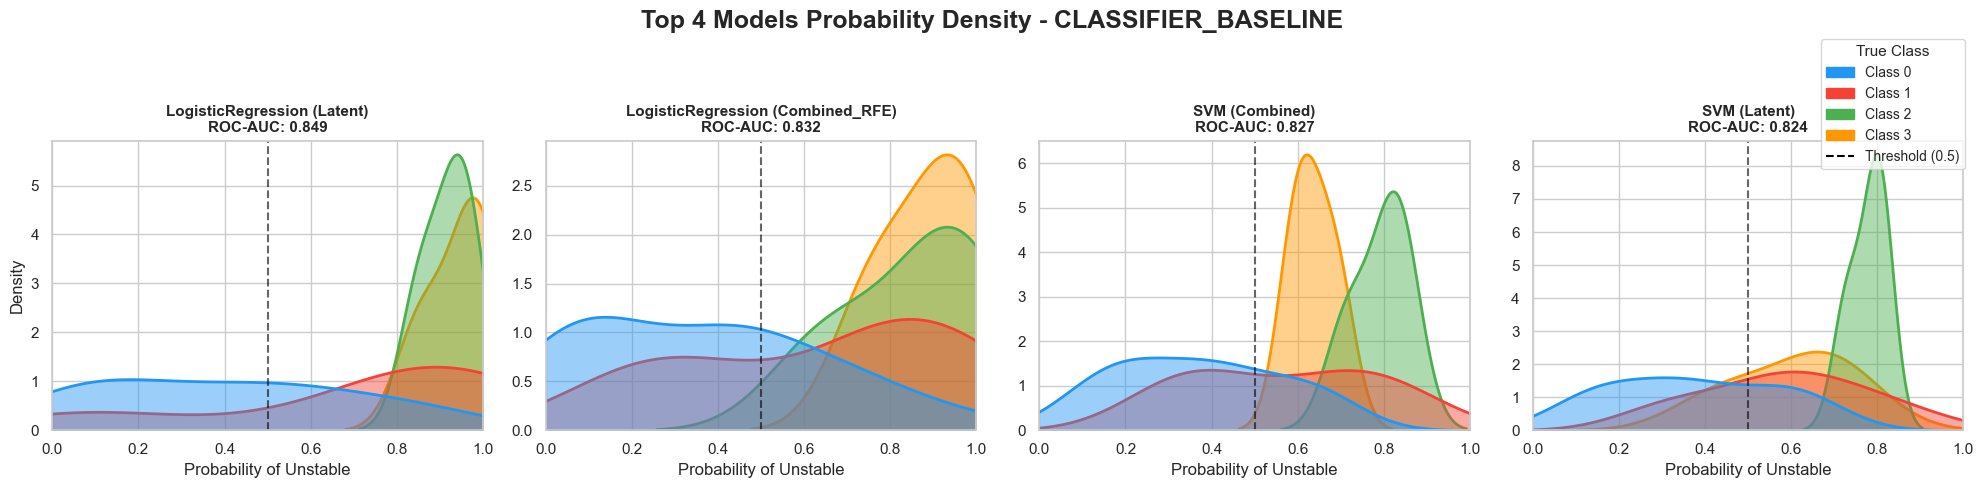

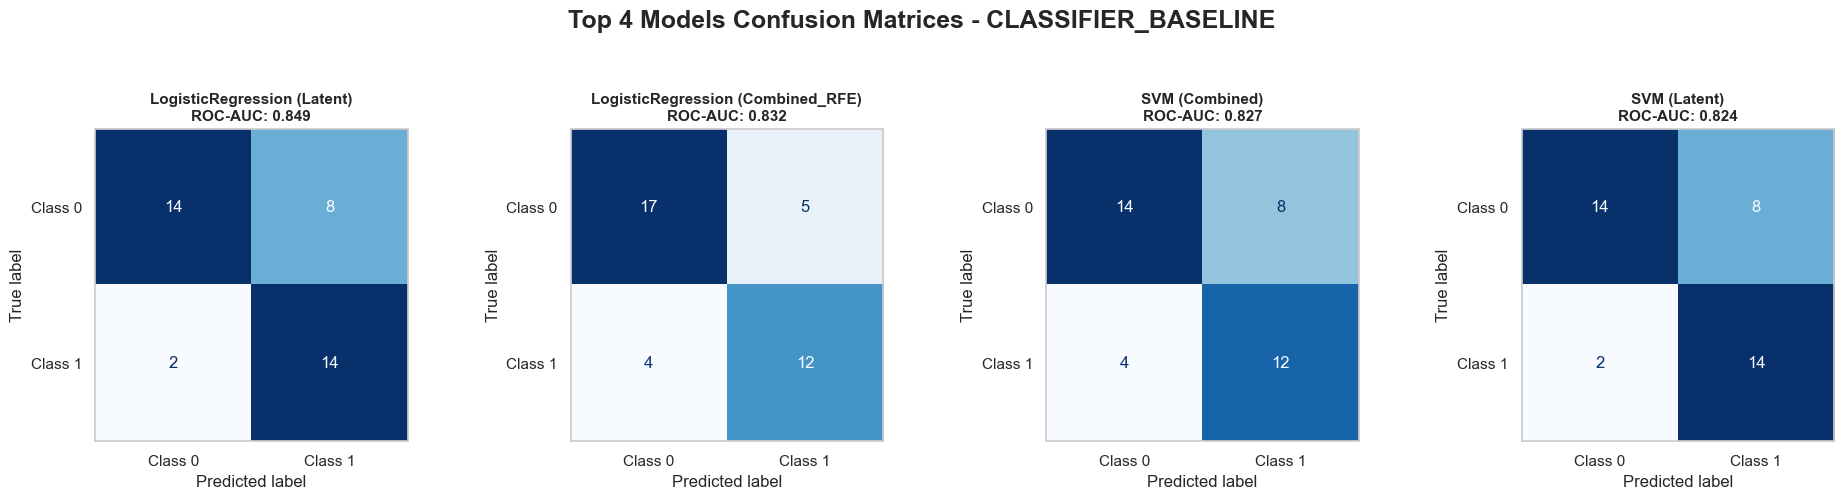


=== Architecture: AUTOENCODER_BASELINE (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. GradientBoosting su Combined_RFE -> ROC-AUC: 0.8551
  2. GradientBoosting su Latent -> ROC-AUC: 0.8466
  3. LogisticRegression su Latent -> ROC-AUC: 0.8324
  4. GradientBoosting su Combined -> ROC-AUC: 0.8295


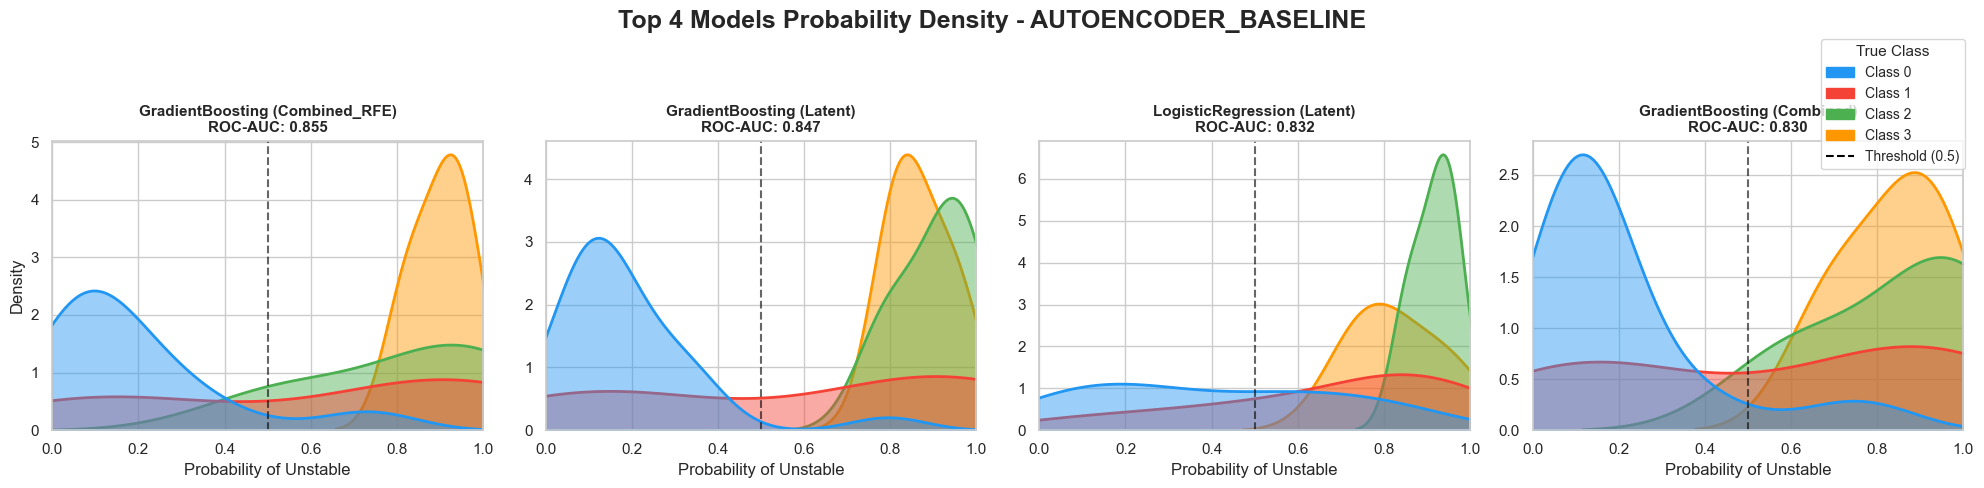

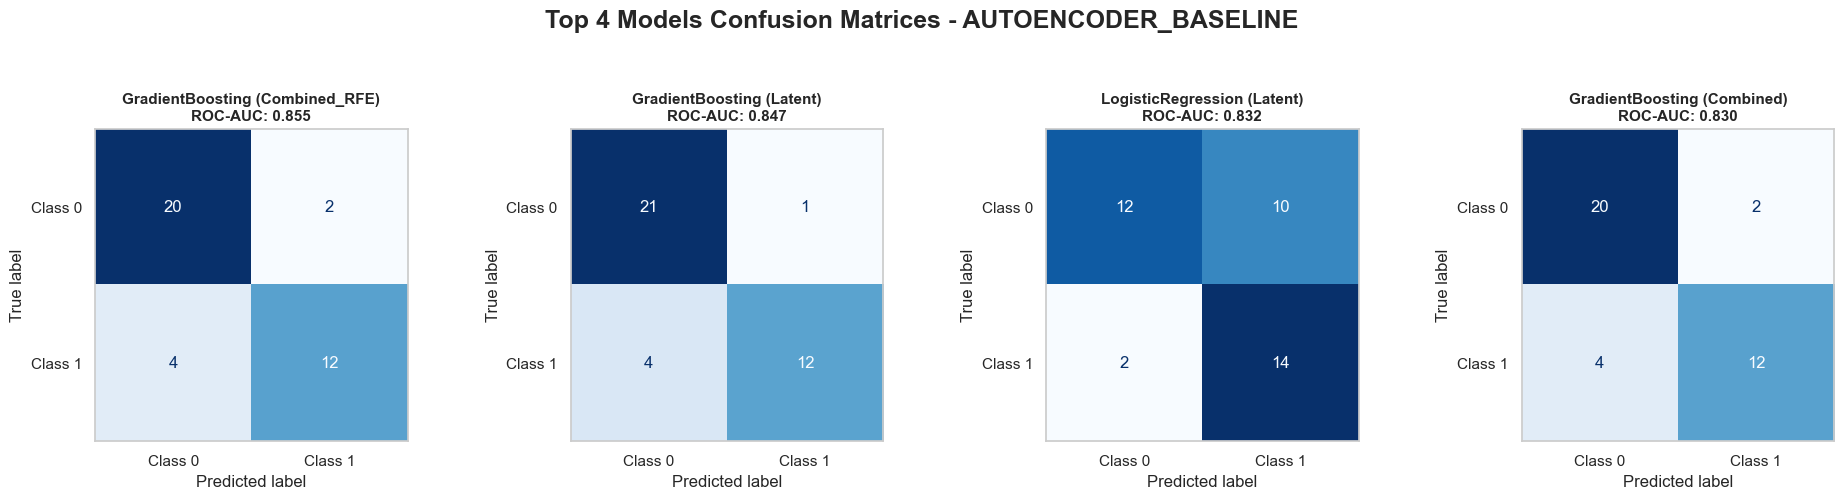


=== Architecture: CLASSIFIER_MMD (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. RandomForest su Latent -> ROC-AUC: 0.9290
  2. SVM su Latent -> ROC-AUC: 0.9290
  3. RandomForest su Combined_RFE -> ROC-AUC: 0.9148
  4. SVM su Combined -> ROC-AUC: 0.9119


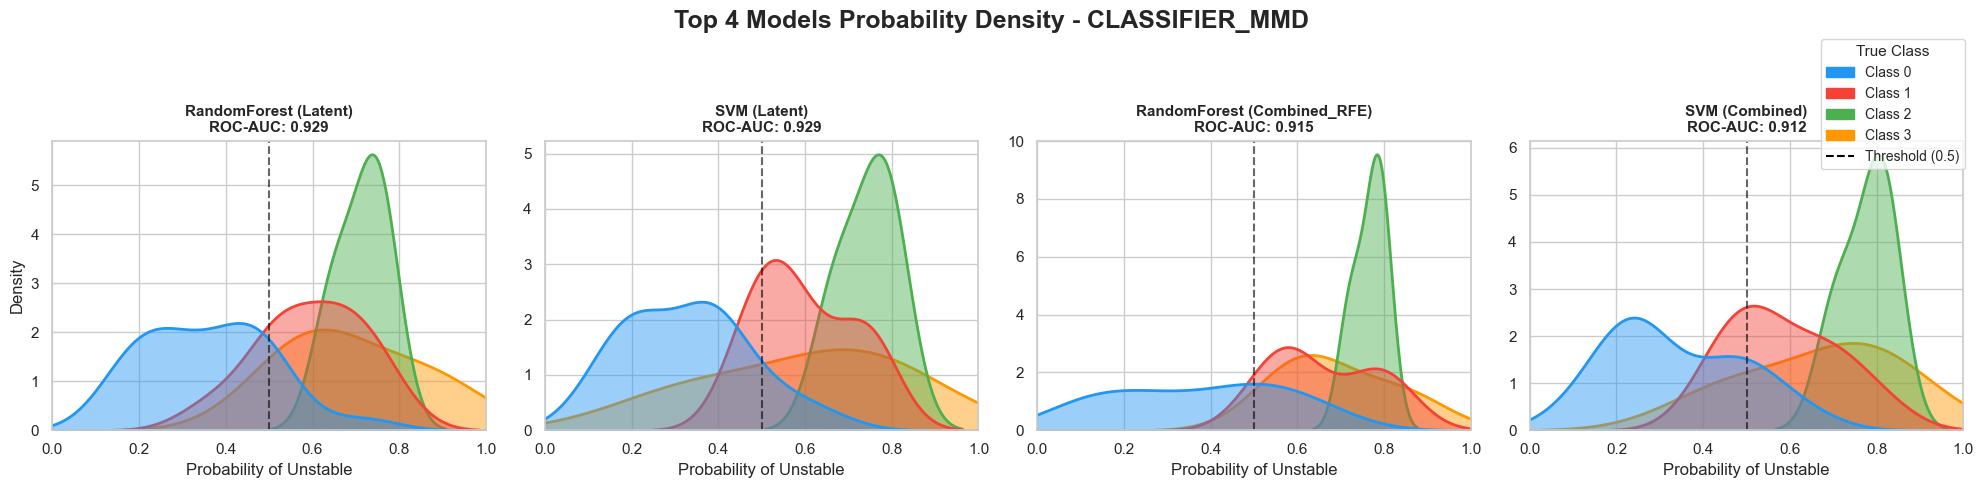

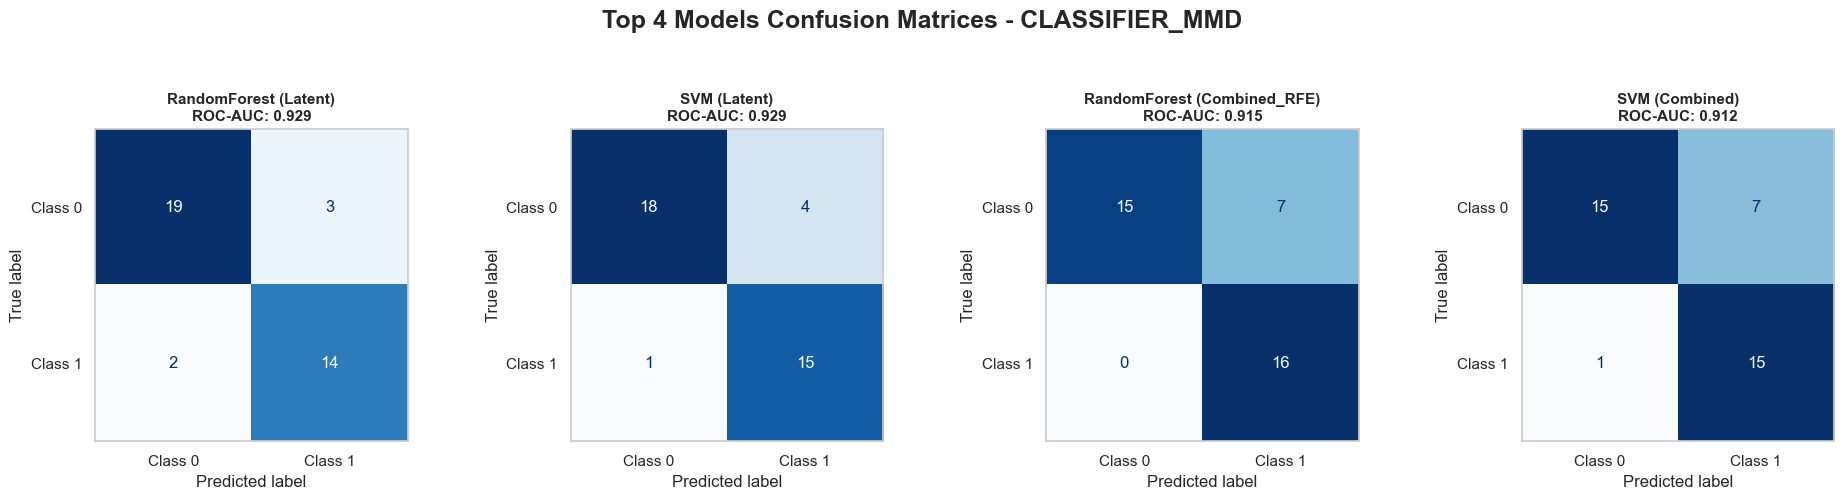


=== Architecture: AUTOENCODER_MMD (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. SVM su Combined -> ROC-AUC: 0.9148
  2. GradientBoosting su Combined -> ROC-AUC: 0.9091
  3. RandomForest su Latent -> ROC-AUC: 0.9006
  4. GradientBoosting su Combined_RFE -> ROC-AUC: 0.9006


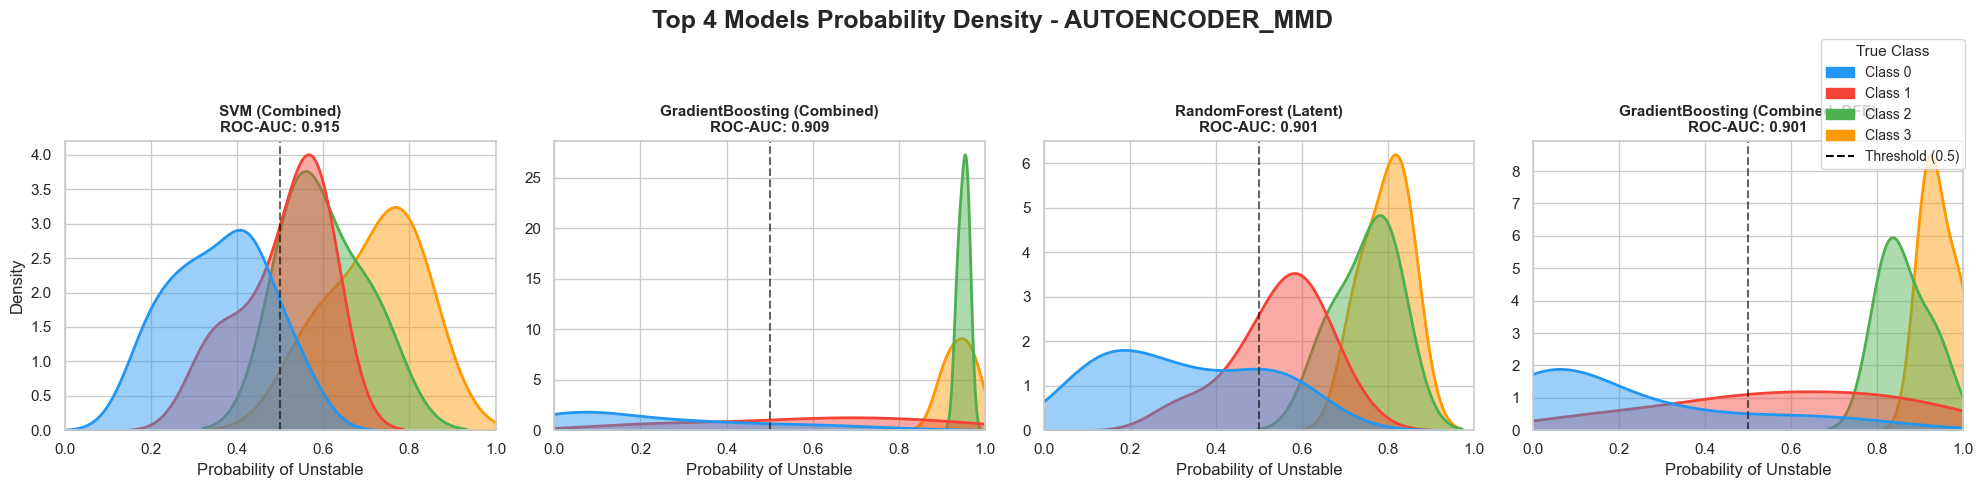

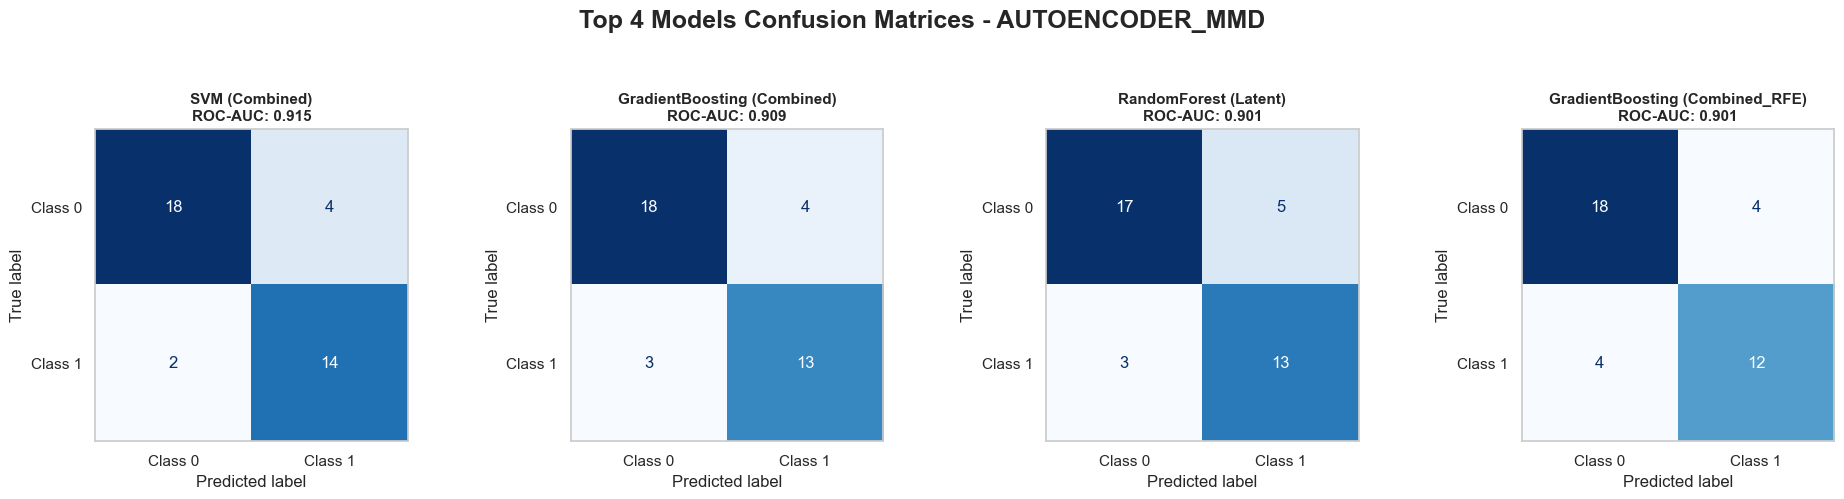


=== Architecture: CLASSIFIER_CORAL (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. RandomForest su Latent -> ROC-AUC: 0.8977
  2. RandomForest su Combined -> ROC-AUC: 0.8977
  3. SVM su Latent -> ROC-AUC: 0.8778
  4. GradientBoosting su Latent -> ROC-AUC: 0.8750


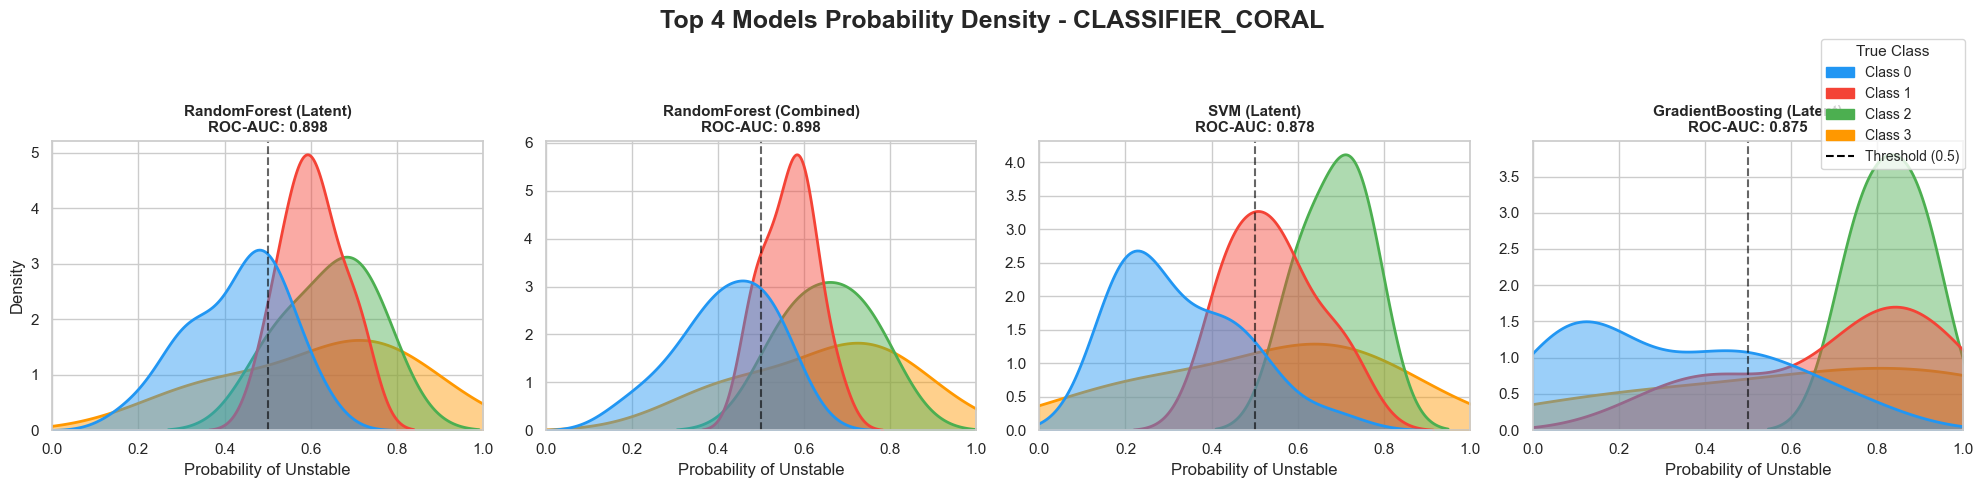

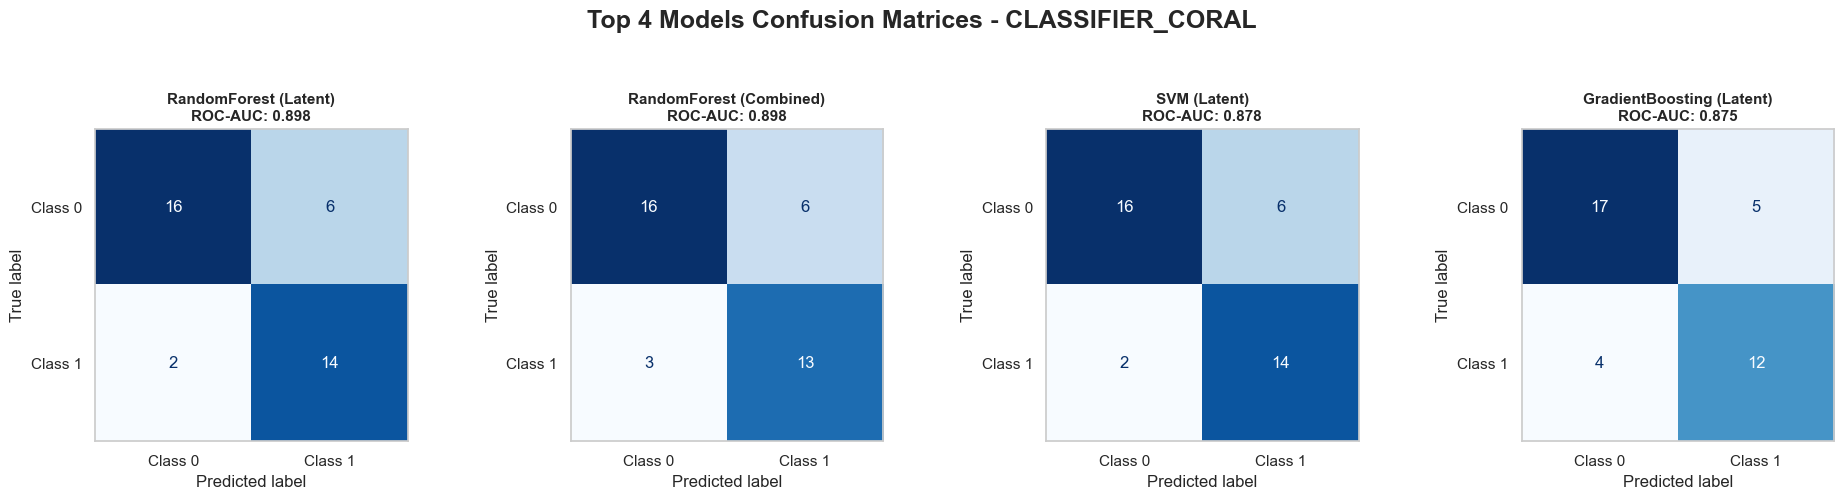


=== Architecture: AUTOENCODER_CORAL (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. SVM su Latent -> ROC-AUC: 0.9034
  2. RandomForest su Combined -> ROC-AUC: 0.8835
  3. RandomForest su Combined_RFE -> ROC-AUC: 0.8580
  4. RandomForest su Latent -> ROC-AUC: 0.8438


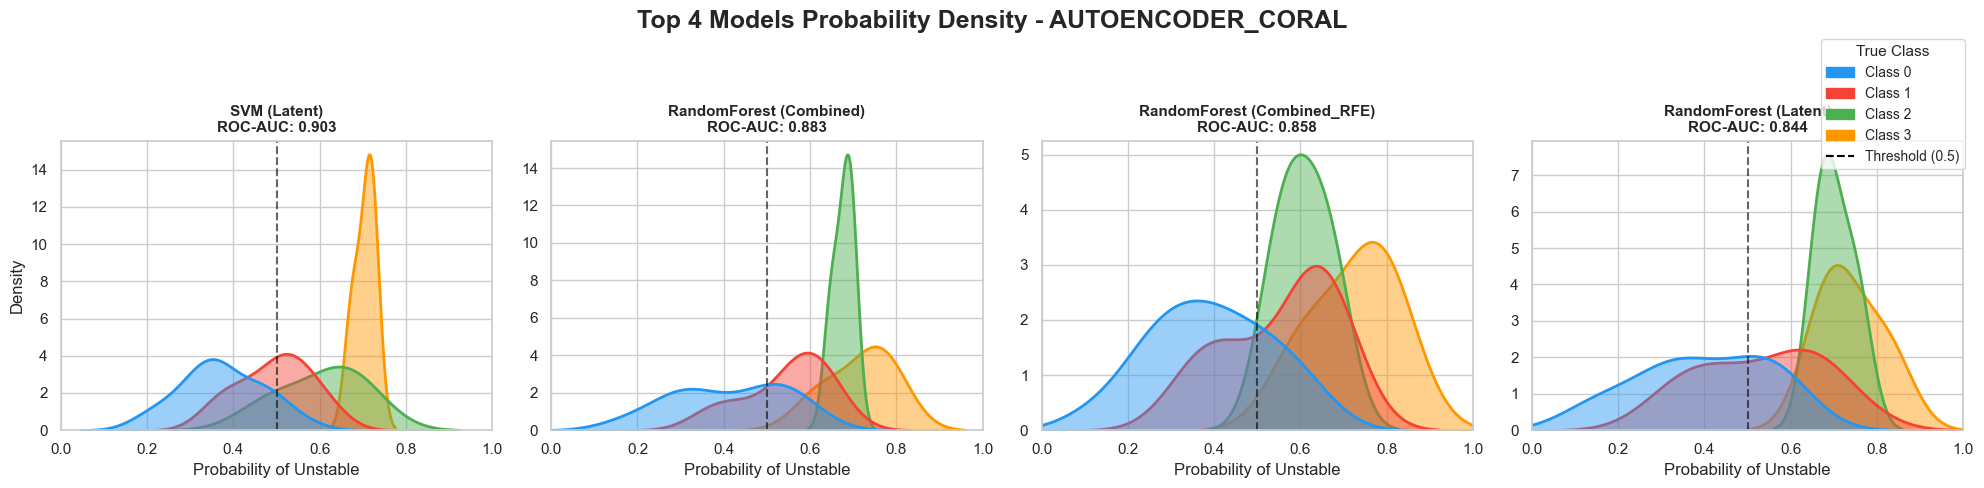

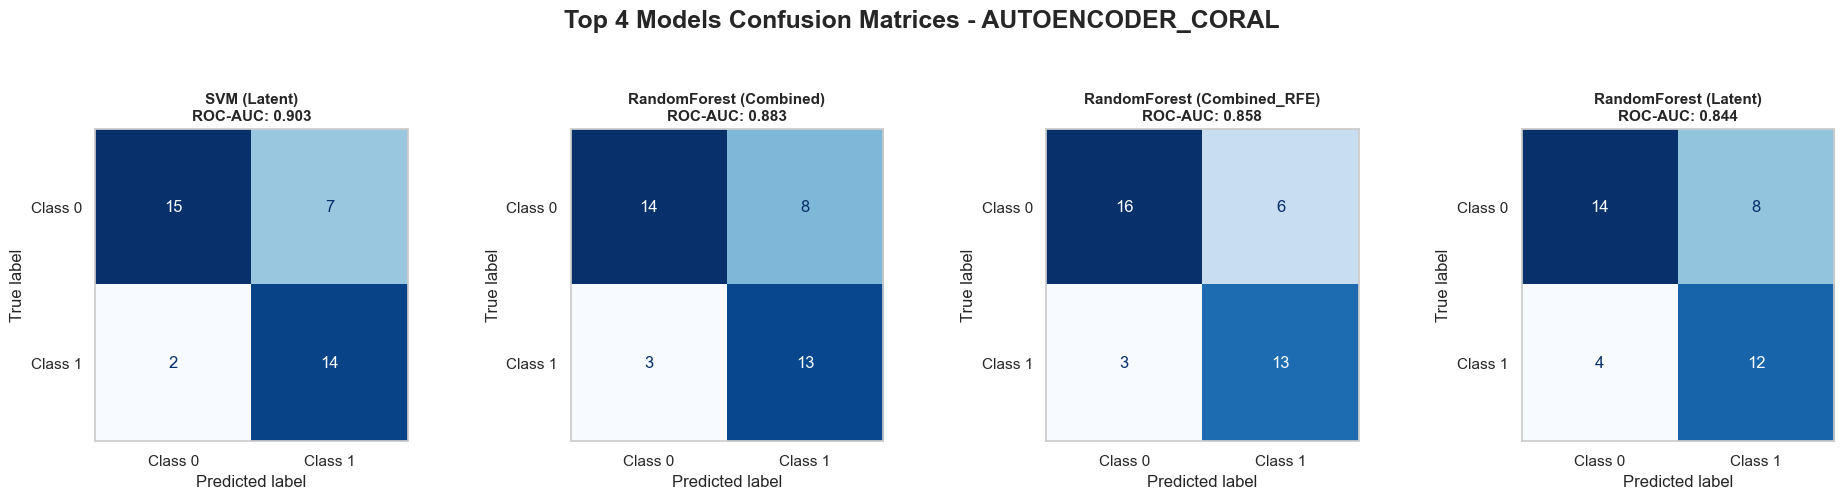

In [4]:
modes = [
    "classifier_baseline", "autoencoder_baseline", 
    "classifier_mmd", "autoencoder_mmd", 
    "classifier_coral", "autoencoder_coral"
]
RESULTS_PATH = "results/"

TOP_N = 4       # Numero di modelli migliori da mostrare per ogni configurazione
METRIC = "ROC-AUC" # Scegli tra "ROC-AUC", "Macro F1", o "Test Acc" per ordinare i migliori

# Colori stabili per le classi
class_colors = {0: "#2196F3", 1: "#F44336", 2: "#4CAF50", 3: "#FF9800"} 
class_labels = {0: "Class 0", 1: "Class 1", 2: "Class 2", 3: "Class 3"}

# =========================================================================
# 2. CARICAMENTO DATI (PREDIZIONI + METRICHE ASSOCIATE)
# =========================================================================
mode_to_df = {}
mode_to_metrics = {}
all_datasets = set()

for mode in modes:
    pred_path = os.path.join(RESULTS_PATH, f"double_ablation_predictions_{mode}.xlsx")
    metrics_path = os.path.join(RESULTS_PATH, f"double_ablation_metrics_{mode}.csv")
    
    # Fallback nel caso in cui i file siano direttamente nella cartella di lavoro corrente
    if not os.path.exists(pred_path): pred_path = f"double_ablation_predictions_{mode}.xlsx"
    if not os.path.exists(metrics_path): metrics_path = f"double_ablation_metrics_{mode}.csv"

    if not os.path.exists(pred_path) or not os.path.exists(metrics_path):
        print(f"[SKIP] File predizioni o metriche mancanti per la modalità '{mode}'")
        continue

    df_mode = pd.read_excel(pred_path)
    df_metrics = pd.read_csv(metrics_path)
    
    mode_to_df[mode] = df_mode
    mode_to_metrics[mode] = df_metrics
    if "dataset" in df_mode.columns:
        all_datasets.update(df_mode["dataset"].dropna().astype(str).unique())

if not mode_to_df:
    raise FileNotFoundError("Nessun set completo di file predizioni/metriche trovato.")

print("Dataset axis used for all architectures:", sorted(all_datasets))
sns.set_theme(style="whitegrid")

# =========================================================================
# 3. PIPELINE DI VISUALIZZAZIONE SUI TOP MODELLI
# =========================================================================
for mode, df in mode_to_df.items():
    
    # Estrae dinamicamente i TOP N modelli basandosi sulle metriche salvate su disco
    metrics_df = mode_to_metrics[mode].copy()
    metrics_df = metrics_df.sort_values(by=METRIC, ascending=False).head(TOP_N)
    top_models = list(zip(metrics_df["Classifier"], metrics_df["Feature Set"], metrics_df[METRIC]))
    
    print(f"\n{'='*75}\n=== Architecture: {mode.upper()} (TOP {TOP_N} PERFORMERS BY {METRIC}) ===\n{'='*75}")
    for idx, (clf, feat, score) in enumerate(top_models):
        print(f"  {idx+1}. {clf} su {feat} -> {METRIC}: {score:.4f}")

    # Impostazione del target di classificazione (4-classi o binario)
    hue_col = "y_true_4cls" if "y_true_4cls" in df.columns else "y_true"
    unique_classes = sorted(df[hue_col].dropna().astype(int).unique())
    palette = {c: class_colors.get(c, "gray") for c in unique_classes}

    # Inizializza layout orizzontali adatti per TOP_N modelli (1 riga, N colonne)
    fig_kde, axes_kde = plt.subplots(1, TOP_N, figsize=(5 * TOP_N, 4.5), sharex=True)
    fig_cm, axes_cm = plt.subplots(1, TOP_N, figsize=(4.8 * TOP_N, 4.5))
    
    # Gestione fallback se TOP_N = 1
    if TOP_N == 1:
        axes_kde, axes_cm = [axes_kde], [axes_cm]

    fig_kde.suptitle(f"Top {TOP_N} Models Probability Density - {mode.upper()}", fontsize=18, fontweight="bold", y=1.08)
    fig_cm.suptitle(f"Top {TOP_N} Models Confusion Matrices - {mode.upper()}", fontsize=18, fontweight="bold", y=1.08)

    for idx, (clf, feat, score) in enumerate(top_models):
        ax_kde = axes_kde[idx]
        ax_cm = axes_cm[idx]
        
        prob_col = f"prob_{clf}_{feat}"
        pred_col = f"y_pred_{clf}_{feat}"
        plot_title = f"{clf} ({feat})\n{METRIC}: {score:.3f}"
        
        if prob_col not in df.columns or pred_col not in df.columns:
            ax_kde.text(0.5, 0.5, f"Colonne Mancanti\n{clf}\n{feat}", ha='center', va='center')
            ax_cm.text(0.5, 0.5, f"Colonne Mancanti\n{clf}\n{feat}", ha='center', va='center')
            ax_kde.grid(False); ax_cm.grid(False)
            continue

        # --- A. PLOT DENSITÀ PROBABILITÀ (KDE) ---
        try:
            sns.kdeplot(
                data=df, x=prob_col, hue=hue_col, fill=True,
                common_norm=False, alpha=0.45, linewidth=2,
                ax=ax_kde, palette=palette, legend=False
            )
        except Exception as e:
            ax_kde.text(0.5, 0.5, "KDE Fallito\n(Varianza insufficiente)", ha='center', va='center')
            
        ax_kde.set_title(plot_title, fontsize=11, fontweight="bold")
        ax_kde.set_xlim(0, 1)
        ax_kde.set_xlabel("Probability of Unstable")
        ax_kde.set_ylabel("Density" if idx == 0 else "")
        ax_kde.axvline(0.5, color="black", linestyle="--", alpha=0.6)

        # --- B. MATRICE DI CONFUSIONE ---
        y_true = df["y_true"].dropna().astype(int)
        y_pred = df[pred_col].loc[y_true.index].astype(int)
        
        cm_labels = sorted(y_true.unique())
        cm = confusion_matrix(y_true, y_pred, labels=cm_labels)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm, 
            display_labels=[class_labels.get(c, str(c)) for c in cm_labels]
        )
        
        disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
        ax_cm.set_title(plot_title, fontsize=11, fontweight="bold")
        ax_cm.grid(False)

    # Aggiunge una legenda globale pulita per il grafico KDE
    legend_handles = [Patch(color=class_colors.get(c, "gray"), label=class_labels.get(c, str(c))) for c in unique_classes]
    legend_handles.append(Line2D([0], [0], color="black", linestyle="--", label="Threshold (0.5)"))
    fig_kde.legend(handles=legend_handles, title="True Class", fontsize=10, title_fontsize=11, 
                   loc='upper right', bbox_to_anchor=(0.99, 1.03))

    # Rendering dei grafici
    fig_kde.tight_layout()
    fig_cm.tight_layout()

    # save
    fig_kde.savefig(f"results/{mode}_top{TOP_N}_kde.png", bbox_inches='tight', dpi=300)
    fig_cm.savefig(f"results/{mode}_top{TOP_N}_cm.png", bbox_inches='tight', dpi=300)
    plt.show()

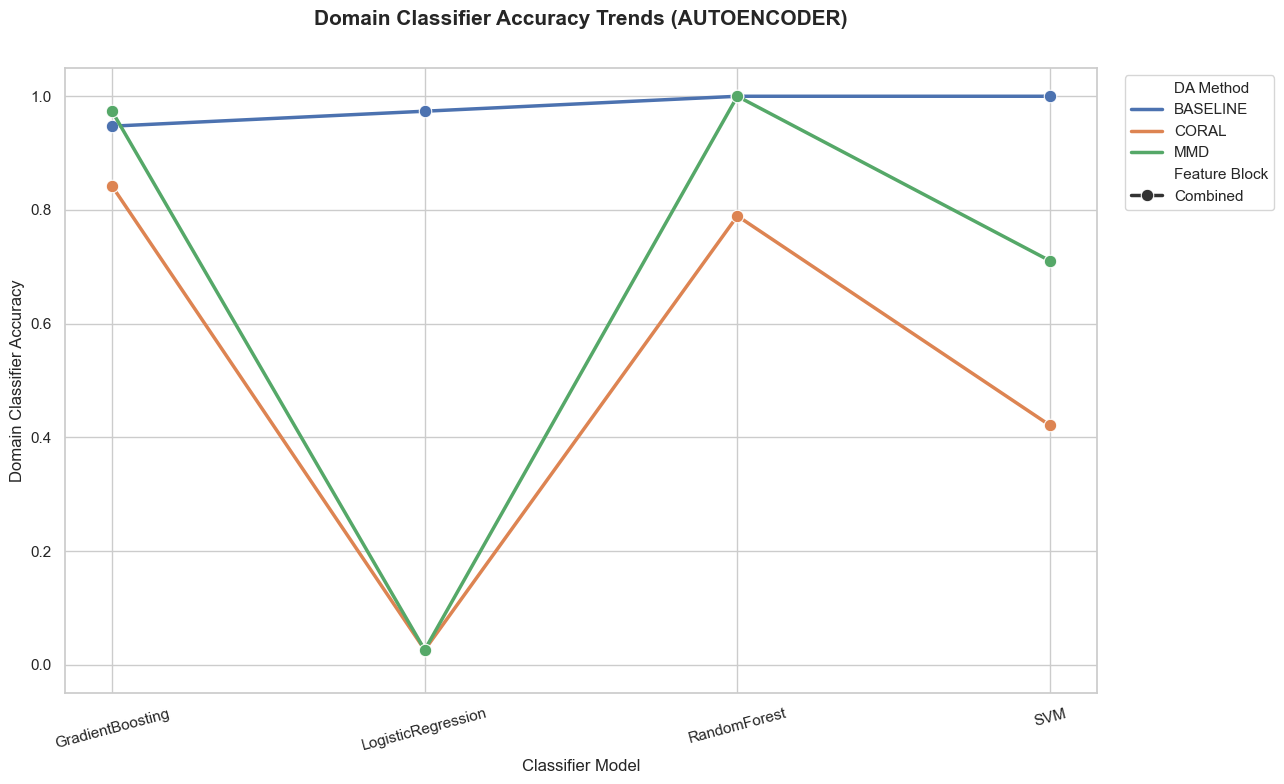

In [5]:
file_path = "results/domain_classifier_comparison.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find '{file_path}'. Check your working directory.")

df = pd.read_csv(file_path)

# Seleziona l'architettura da ispezionare ('autoencoder' o 'classifier')
ARCH_MODE = "autoencoder" 
df_sub = df[df["Arch Mode"] == ARCH_MODE]

# =========================================================================
# 2. RIORGANIZZAZIONE DATI PER IL LINEPLOT
# =========================================================================
# Poiché il file di confronto separa l'accuratezza in 'Acc_baseline' e 'Acc_da',
# dobbiamo unirle in un'unica colonna 'Accuracy' con una colonna identificativa 'DA Method'.

# 1. Estrai i dati relativi alle varianti DA (Coral e MMD)
df_da = df_sub[["Feature Block", "Model", "DA Variant", "Acc_da"]].copy()
df_da.columns = ["Feature Block", "Model", "DA Method", "Accuracy"]
df_da["DA Method"] = df_da["DA Method"].str.upper()

# 2. Estrai i dati unici della Baseline
df_base = df_sub[["Feature Block", "Model", "Acc_baseline"]].drop_duplicates().copy()
df_base["DA Method"] = "BASELINE"
df_base.columns = ["Feature Block", "Model", "Accuracy", "DA Method"]

# 3. Unisci i blocchi in un unico DataFrame pronto per il grafico
df_plot = pd.concat([df_base, df_da], ignore_index=True)

# Configura gli ordini espliciti degli assi e delle legende
feature_blocks = ["Combined"]
classifiers = ["RandomForest", "GradientBoosting", "SVM", "LogisticRegression"]
da_order = ["BASELINE", "CORAL", "MMD"]

# =========================================================================
# 3. GENERAZIONE DEL LINEPLOT
# =========================================================================
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(13, 8))

# Colori dedicati stabili per Baseline, Coral e MMD
colors = {"BASELINE": "#4C72B0", "CORAL": "#DD8452", "MMD": "#55A868"}

sns.lineplot(
    data=df_plot, 
    x="Model", 
    y="Accuracy", 
    hue="DA Method", 
    style="Feature Block", 
    markers=True, 
    dashes=True,       # Lasciare True aiuta a distinguere i blocchi di feature tramite tratteggi diversi
    linewidth=2.5,
    markersize=9,
    palette=colors,
    hue_order=da_order,
    style_order=feature_blocks,
    sort=False         # Evita che Seaborn riordini alfabeticamente i modelli sull'asse X
)

# Formattazione e dettagli assi
plt.title(f"Domain Classifier Accuracy Trends ({ARCH_MODE.upper()})\n"
          , fontsize=15, fontweight="bold", pad=15)
plt.ylabel("Domain Classifier Accuracy", fontsize=12)
plt.xlabel("Classifier Model", fontsize=12)
plt.ylim(-0.05, 1.05)

# Posiziona la legenda esternamente a destra per evitare sovrapposizioni con le linee
plt.legend( fontsize=11, title_fontsize=12, loc="upper left", bbox_to_anchor=(1.02, 1))

plt.xticks(rotation=15, fontsize=11)
plt.tight_layout()
plt.savefig(f"results/{ARCH_MODE}_domain_classifier_trends.png", bbox_inches='tight', dpi=300)
plt.show()

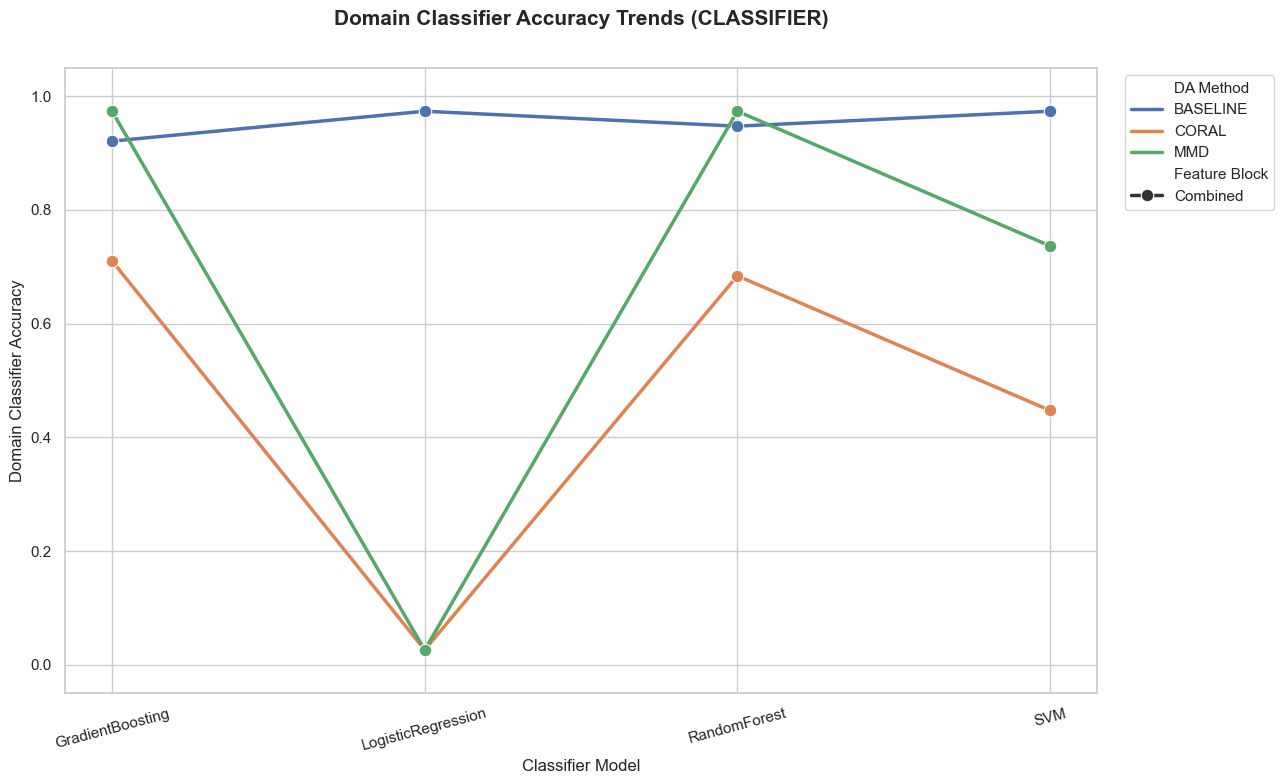

In [6]:
file_path = "results/domain_classifier_comparison.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find '{file_path}'. Check your working directory.")

df = pd.read_csv(file_path)

# Seleziona l'architettura da ispezionare ('autoencoder' o 'classifier')
ARCH_MODE = "classifier" 
df_sub = df[df["Arch Mode"] == ARCH_MODE]

# =========================================================================
# 2. RIORGANIZZAZIONE DATI PER IL LINEPLOT
# =========================================================================
# Poiché il file di confronto separa l'accuratezza in 'Acc_baseline' e 'Acc_da',
# dobbiamo unirle in un'unica colonna 'Accuracy' con una colonna identificativa 'DA Method'.

# 1. Estrai i dati relativi alle varianti DA (Coral e MMD)
df_da = df_sub[["Feature Block", "Model", "DA Variant", "Acc_da"]].copy()
df_da.columns = ["Feature Block", "Model", "DA Method", "Accuracy"]
df_da["DA Method"] = df_da["DA Method"].str.upper()

# 2. Estrai i dati unici della Baseline
df_base = df_sub[["Feature Block", "Model", "Acc_baseline"]].drop_duplicates().copy()
df_base["DA Method"] = "BASELINE"
df_base.columns = ["Feature Block", "Model", "Accuracy", "DA Method"]

# 3. Unisci i blocchi in un unico DataFrame pronto per il grafico
df_plot = pd.concat([df_base, df_da], ignore_index=True)

# Configura gli ordini espliciti degli assi e delle legende
feature_blocks = ["Combined"]
classifiers = ["RandomForest", "GradientBoosting", "SVM", "LogisticRegression"]
da_order = ["BASELINE", "CORAL", "MMD"]

# =========================================================================
# 3. GENERAZIONE DEL LINEPLOT
# =========================================================================
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(13, 8))

# Colori dedicati stabili per Baseline, Coral e MMD
colors = {"BASELINE": "#4C72B0", "CORAL": "#DD8452", "MMD": "#55A868"}

sns.lineplot(
    data=df_plot, 
    x="Model", 
    y="Accuracy", 
    hue="DA Method", 
    style="Feature Block", 
    markers=True, 
    dashes=True,       # Lasciare True aiuta a distinguere i blocchi di feature tramite tratteggi diversi
    linewidth=2.5,
    markersize=9,
    palette=colors,
    hue_order=da_order,
    style_order=feature_blocks,
    sort=False         # Evita che Seaborn riordini alfabeticamente i modelli sull'asse X
)

# Formattazione e dettagli assi
plt.title(f"Domain Classifier Accuracy Trends ({ARCH_MODE.upper()})\n"
          , fontsize=15, fontweight="bold", pad=15)
plt.ylabel("Domain Classifier Accuracy", fontsize=12)
plt.xlabel("Classifier Model", fontsize=12)
plt.ylim(-0.05, 1.05)

# Posiziona la legenda esternamente a destra per evitare sovrapposizioni con le linee
plt.legend( fontsize=11, title_fontsize=12, loc="upper left", bbox_to_anchor=(1.02, 1))

plt.xticks(rotation=15, fontsize=11)
plt.tight_layout()
plt.savefig(f"results/{ARCH_MODE}_domain_classifier_trends.png", bbox_inches='tight', dpi=300)
plt.show()

In [8]:
# print value counts of label in train and test set
df_train = pd.read_csv("models/train_features_enriched_autoencoder_baseline.csv")
df_test = pd.read_csv("models/test_features_enriched_autoencoder_baseline.csv")
print("Train set label counts:")
print(df_train['y_true_4cls'].value_counts())
print("\nTest set label counts:")
print(df_test['y_true_4cls'].value_counts())

Train set label counts:
y_true_4cls
0    65
1    24
3    13
2     9
Name: count, dtype: int64

Test set label counts:
y_true_4cls
0    22
1    10
2     3
3     3
Name: count, dtype: int64
